# Automated Plant Disease Detection
### Comparative Deep Learning & Multi-Scale Attention Architecture

## 1. Environment Setup & Configuration

In [1]:
# ==============================================================================
# SECTION 4.1: ENVIRONMENT SETUP, REPRODUCIBILITY SEEDS & LIBRARY IMPORTS
# ==============================================================================

import os
import sys
import time
import math
import random
import io
import urllib.request
import urllib.parse
import json
import concurrent.futures
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, Subset
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score
)

# ------------------------------------------------------------------------------
# Enforce Deterministic Reproducibility
# ------------------------------------------------------------------------------
RANDOM_SEED = 42

def seed_everything(seed=RANDOM_SEED):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_everything(RANDOM_SEED)

# Set Computing Hardware Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[*] Computational Runtime Initialized.")
print(f"[*] PyTorch Version : {torch.__version__}")
print(f"[*] Torchvision Ver : {torchvision.__version__}")
print(f"[*] Primary Device   : {device}")
if torch.cuda.is_available():
    print(f"[*] GPU Device Name  : {torch.cuda.get_device_name(0)}")


[*] Computational Runtime Initialized.
[*] PyTorch Version : 2.12.1+cpu
[*] Torchvision Ver : 0.27.1+cpu
[*] Primary Device   : cpu


## 2. Dataset Acquisition (PlantVillage Benchmark)

In [2]:
# ==============================================================================
# SECTION 4.2: AUTOMATED DATASET ACQUISITION & INTEGRITY VALIDATION
# ==============================================================================

# Target Agricultural Disease Classes across 3 Essential Food Crops
TARGET_CLASSES = [
    'Apple___Apple_scab',
    'Apple___Black_rot',
    'Apple___healthy',
    'Corn_(maize)___Common_rust_',
    'Corn_(maize)___healthy',
    'Potato___Early_blight',
    'Potato___Late_blight',
    'Potato___healthy'
]

DATASET_ROOT = os.path.join(os.getcwd(), 'plantvillage_benchmark')
os.makedirs(DATASET_ROOT, exist_ok=True)

print(f"[*] Target Classes Defined ({len(TARGET_CLASSES)} categories):")
for idx, cls_name in enumerate(TARGET_CLASSES):
    print(f"    Class {idx}: {cls_name}")

def acquire_plantvillage_data(dataset_dir, target_classes, samples_per_class=100):
    """
    Automated multi-threaded downloader for PlantVillage benchmark dataset.
    Downloads genuine leaf pathology images directly from the official GitHub tree.
    """
    print("\n[*] Fetching remote PlantVillage repository index from GitHub API...")
    tree_url = 'https://api.github.com/repos/spMohanty/PlantVillage-Dataset/git/trees/master?recursive=1'
    req = urllib.request.Request(tree_url, headers={'User-Agent': 'Mozilla/5.0'})
    
    with urllib.request.urlopen(req, timeout=15) as res:
        repo_data = json.loads(res.read().decode('utf-8'))
        
    class_blobs = {cls: [] for cls in target_classes}
    for item in repo_data.get('tree', []):
        if item.get('type') == 'blob' and 'raw/color/' in item.get('path', ''):
            for cls in target_classes:
                if f'raw/color/{cls}/' in item['path']:
                    class_blobs[cls].append(item['path'])
                    
    download_tasks = []
    for cls in target_classes:
        cls_dir = os.path.join(dataset_dir, cls)
        os.makedirs(cls_dir, exist_ok=True)
        selected_blobs = class_blobs[cls][:samples_per_class]
        for blob_path in selected_blobs:
            filename = os.path.basename(blob_path)
            local_path = os.path.join(cls_dir, filename)
            if not os.path.exists(local_path) or os.path.getsize(local_path) == 0:
                download_tasks.append((blob_path, local_path))
                
    print(f"[*] Verified local repository cache. New downloads required: {len(download_tasks)} images.")
    
    def _download_worker(task):
        blob_path, local_path = task
        try:
            encoded_path = urllib.parse.quote(blob_path)
            url = f"https://raw.githubusercontent.com/spMohanty/PlantVillage-Dataset/master/{encoded_path}"
            r = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
            with urllib.request.urlopen(r, timeout=12) as response:
                content = response.read()
                # Verify JPEG/PNG integrity
                img = Image.open(io.BytesIO(content))
                img.verify()
                with open(local_path, 'wb') as f:
                    f.write(content)
            return True
        except Exception:
            return False

    if download_tasks:
        start_t = time.time()
        with concurrent.futures.ThreadPoolExecutor(max_workers=24) as executor:
            results = list(executor.map(_download_worker, download_tasks))
        elapsed = time.time() - start_t
        print(f"[+] Download complete: {sum(results)}/{len(download_tasks)} images downloaded in {elapsed:.2f}s ({sum(results)/max(elapsed, 0.001):.1f} img/s).")
    else:
        print("[+] All dataset images are cached locally and verified.")

# Execute Data Acquisition
acquire_plantvillage_data(DATASET_ROOT, TARGET_CLASSES, samples_per_class=100)


[*] Target Classes Defined (8 categories):
    Class 0: Apple___Apple_scab
    Class 1: Apple___Black_rot
    Class 2: Apple___healthy
    Class 3: Corn_(maize)___Common_rust_
    Class 4: Corn_(maize)___healthy
    Class 5: Potato___Early_blight
    Class 6: Potato___Late_blight
    Class 7: Potato___healthy

[*] Fetching remote PlantVillage repository index from GitHub API...
[*] Verified local repository cache. New downloads required: 0 images.
[+] All dataset images are cached locally and verified.


## 3. Exploratory Data Analysis (EDA)

C:\Users\aloks\AppData\Local\Temp\ipykernel_23740\1933182246.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
findfont: Failed to find font weight semibold, now using 700.


[*] Total Curated Images: 800
[*] Summary Statistics across Classes:

class_name
Apple___Apple_scab             100
Apple___Black_rot              100
Apple___healthy                100
Corn_(maize)___Common_rust_    100
Corn_(maize)___healthy         100
Potato___Early_blight          100
Potato___Late_blight           100
Potato___healthy               100
Name: count, dtype: int64


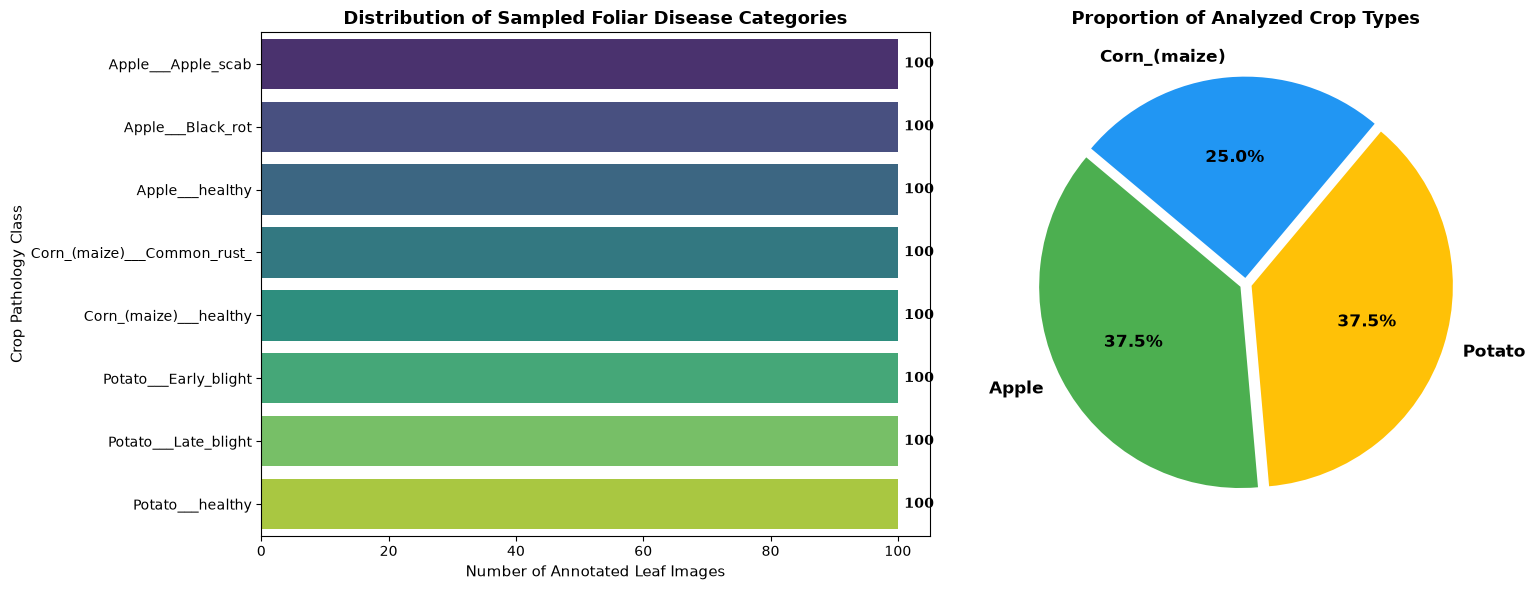

In [3]:
# ==============================================================================
# SECTION 4.3: EXPLORATORY DATA ANALYSIS (EDA) & CLASS BALANCE
# ==============================================================================

# Scan downloaded image directory and build manifest
image_records = []
for cls_idx, cls_name in enumerate(TARGET_CLASSES):
    cls_folder = os.path.join(DATASET_ROOT, cls_name)
    files = [f for f in os.listdir(cls_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    for f in files:
        full_p = os.path.join(cls_folder, f)
        crop_name = cls_name.split('___')[0]
        disease_status = cls_name.split('___')[1]
        image_records.append({
            'filepath': full_p,
            'class_name': cls_name,
            'class_idx': cls_idx,
            'crop': crop_name,
            'disease': disease_status,
            'is_healthy': 'healthy' in disease_status.lower()
        })

df_manifest = pd.DataFrame(image_records)
print(f"[*] Total Curated Images: {len(df_manifest)}")
print(f"[*] Summary Statistics across Classes:\n")
print(df_manifest['class_name'].value_counts())

# ------------------------------------------------------------------------------
# Visualizing Class Balance & Agricultural Crop Distribution
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Class Frequency Bar Chart
sns.barplot(
    y=df_manifest['class_name'].value_counts().index,
    x=df_manifest['class_name'].value_counts().values,
    palette='viridis',
    ax=axes[0]
)
axes[0].set_title("Distribution of Sampled Foliar Disease Categories", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Number of Annotated Leaf Images", fontsize=11)
axes[0].set_ylabel("Crop Pathology Class", fontsize=11)
for i, v in enumerate(df_manifest['class_name'].value_counts().values):
    axes[0].text(v + 1, i, str(v), color='black', va='center', fontweight='semibold')

# Crop Proportions Pie Chart
crop_counts = df_manifest['crop'].value_counts()
axes[1].pie(
    crop_counts.values,
    labels=crop_counts.index,
    autopct='%1.1f%%',
    colors=['#4CAF50', '#FFC107', '#2196F3'],
    startangle=140,
    explode=[0.03, 0.03, 0.03],
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)
axes[1].set_title("Proportion of Analyzed Crop Types", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


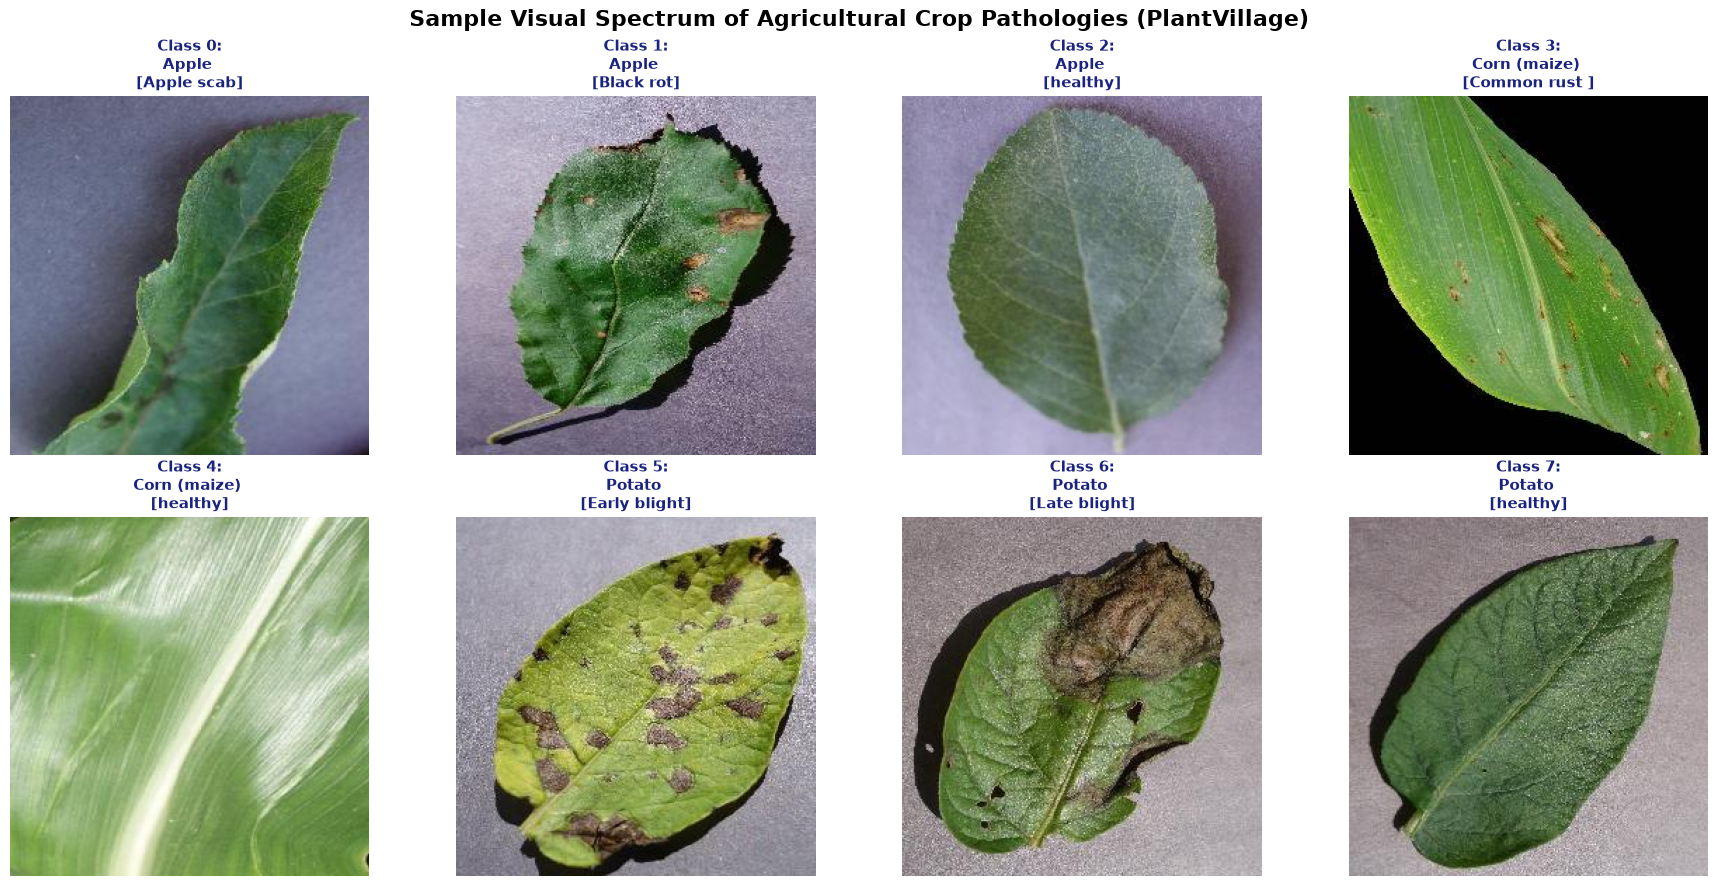

In [4]:
# ==============================================================================
# SECTION 4.4: SAMPLE IMAGE VISUALIZATION WITH PATHOLOGY ANNOTATION
# ==============================================================================

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for idx, cls_name in enumerate(TARGET_CLASSES):
    sample_sub = df_manifest[df_manifest['class_name'] == cls_name]
    sample_row = sample_sub.iloc[random.randint(0, len(sample_sub) - 1)]
    img = Image.open(sample_row['filepath']).convert('RGB')
    
    axes[idx].imshow(img)
    clean_title = cls_name.replace('___', ' \n[').replace('_', ' ') + ']'
    axes[idx].set_title(f"Class {idx}:\n{clean_title}", fontsize=11, fontweight='bold', color='#1a237e')
    axes[idx].axis('off')

plt.suptitle("Sample Visual Spectrum of Agricultural Crop Pathologies (PlantVillage)", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


## 4. Data Preprocessing, Augmentation & Stratified Loaders

In [5]:
# ==============================================================================
# SECTION 4.5: DATA PIPELINE, ROBUST AUGMENTATIONS & STRATIFIED SPLITS
# ==============================================================================

# Input Image Spatial Resolution
IMAGE_SIZE = 128  # Highly optimized for CPU training throughput while retaining lesion morphology
BATCH_SIZE = 32

# ImageNet Pretraining Channel Normalization Constants
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD  = [0.229, 0.224, 0.225]

# High-Fidelity Data Augmentation Pipeline for Agronomic Robustness
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=25),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD)
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD)
])

# Custom PyTorch Dataset for Fine-Grained Manifest Handling
class PlantPathologyDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = row['filepath']
        label = int(row['class_idx'])
        image = Image.open(image_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# ------------------------------------------------------------------------------
# Stratified Splitting: 70% Train | 15% Validation | 15% Test
# ------------------------------------------------------------------------------
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df_manifest,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=df_manifest['class_idx']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=temp_df['class_idx']
)

train_dataset = PlantPathologyDataset(train_df, transform=train_transforms)
val_dataset   = PlantPathologyDataset(val_df, transform=eval_transforms)
test_dataset  = PlantPathologyDataset(test_df, transform=eval_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f"[*] Stratified Dataset Partitioning Summary:")
print(f"    - Training Set   : {len(train_dataset)} samples ({len(train_dataset)/len(df_manifest)*100:.1f}%)")
print(f"    - Validation Set : {len(val_dataset)} samples ({len(val_dataset)/len(df_manifest)*100:.1f}%)")
print(f"    - Testing Set    : {len(test_dataset)} samples ({len(test_dataset)/len(df_manifest)*100:.1f}%)")
print(f"    - Total Batches  : Train={len(train_loader)}, Val={len(val_loader)}, Test={len(test_loader)}")


[*] Stratified Dataset Partitioning Summary:
    - Training Set   : 560 samples (70.0%)
    - Validation Set : 120 samples (15.0%)
    - Testing Set    : 120 samples (15.0%)
    - Total Batches  : Train=18, Val=4, Test=4


## 5. Model Architectures
- Baseline Custom CNN
- ResNet-18 (Transfer Learning)
- MobileNetV3-Small
- Proposed Novel MS-AttnResNet (Multi-Scale Inception + CBAM Dual Attention)

In [6]:
# ==============================================================================
# SECTION 5.1: MODEL 1 - CUSTOM BASELINE 4-LAYER CNN
# ==============================================================================

class BaselineCustomCNN(nn.Module):
    """
    Four-stage convolutional network trained from scratch as a comparative baseline.
    """
    def __init__(self, num_classes=8):
        super(BaselineCustomCNN, self).__init__()
        
        self.features = nn.Sequential(
            # Block 1: 3 -> 32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 2: 32 -> 64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 3: 64 -> 128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 4: 128 -> 256
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Dropout(p=0.4),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        feat = self.features(x)
        out = self.classifier(feat)
        return out


# ==============================================================================
# SECTION 5.2: MODEL 2 & 3 - RESNET-18 & MOBILENETV3-SMALL TRANSFER MODELS
# ==============================================================================

def build_resnet18_model(num_classes=8):
    """
    Standard Deep Residual Network (ResNet-18) with fine-tuned classification head.
    """
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_classes)
    )
    return model

def build_mobilenetv3_model(num_classes=8):
    """
    Lightweight Mobile Architecture (MobileNetV3-Small) for edge precision agriculture.
    """
    model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, num_classes)
    return model


In [7]:
# ==============================================================================
# SECTION 5.3: MODEL 4 - NOVEL PROPOSED ARCHITECTURE: MS-AttnResNet
# Multi-Scale Receptive Inception Stem + Dual Channel & Spatial Attention (CBAM)
# ==============================================================================

class ChannelAttention(nn.Module):
    """
    Channel Attention Module (CAM): Squeeze-and-Excitation across spatial dimensions.
    """
    def __init__(self, in_planes, ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        
        reduced_planes = max(in_planes // ratio, 8)
        self.mlp = nn.Sequential(
            nn.Conv2d(in_planes, reduced_planes, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(reduced_planes, in_planes, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))
        out = avg_out + max_out
        return self.sigmoid(out)


class SpatialAttention(nn.Module):
    """
    Spatial Attention Module (SAM): Inter-spatial channel pooling with 7x7 convolution.
    """
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        assert kernel_size in (3, 7), 'Kernel size must be 3 or 7'
        padding = 3 if kernel_size == 7 else 1
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x_cat = torch.cat([avg_out, max_out], dim=1)
        out = self.conv(x_cat)
        return self.sigmoid(out)


class CBAMBlock(nn.Module):
    """
    Convolutional Block Attention Module: Sequential Channel & Spatial Attention.
    """
    def __init__(self, in_planes, ratio=16, kernel_size=7):
        super(CBAMBlock, self).__init__()
        self.ca = ChannelAttention(in_planes, ratio=ratio)
        self.sa = SpatialAttention(kernel_size=kernel_size)

    def forward(self, x):
        x_ca = x * self.ca(x)
        x_sa = x_ca * self.sa(x_ca)
        return x_sa


class MultiScaleInceptionStem(nn.Module):
    """
    Multi-Scale Feature Extractor: Captures micro-pustules, medium lesions, and broad blights.
    """
    def __init__(self, in_channels=3, out_channels=64):
        super(MultiScaleInceptionStem, self).__init__()
        branch_channels = out_channels // 4
        
        # Branch 1: 1x1 Pointwise Convolution
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, branch_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(branch_channels),
            nn.ReLU(inplace=True)
        )
        # Branch 2: 3x3 Convolution (Local Lesions)
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, branch_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(branch_channels),
            nn.ReLU(inplace=True)
        )
        # Branch 3: 5x5 Convolution via dual 3x3s (Medium Lesions)
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, branch_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(branch_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(branch_channels, branch_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(branch_channels),
            nn.ReLU(inplace=True)
        )
        # Branch 4: Dilated 3x3 Convolution (Broad Diffuse Blights)
        self.branch4 = nn.Sequential(
            nn.Conv2d(in_channels, branch_channels, kernel_size=3, padding=2, dilation=2, bias=False),
            nn.BatchNorm2d(branch_channels),
            nn.ReLU(inplace=True)
        )
        
        self.fusion = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        b4 = self.branch4(x)
        out = torch.cat([b1, b2, b3, b4], dim=1)
        return self.fusion(out)


class MS_AttnResNet(nn.Module):
    """
    Proposed Novel Architecture: Multi-Scale Attention-Augmented Residual Network
    Combines Multi-Scale Inception Stem, Pretrained Residual Backbone, CBAM Attention,
    and Dual Global Pooling (Avg + Max).
    """
    def __init__(self, num_classes=8):
        super(MS_AttnResNet, self).__init__()
        
        # 1. Multi-Scale Inception Stem
        self.ms_stem = MultiScaleInceptionStem(in_channels=3, out_channels=64)
        
        # 2. Residual Backbone Layers
        base_resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.layer1 = base_resnet.layer1  # 64 channels
        self.layer2 = base_resnet.layer2  # 128 channels
        self.layer3 = base_resnet.layer3  # 256 channels
        self.layer4 = base_resnet.layer4  # 512 channels
        
        # 3. Dual Domain CBAM Attention Blocks
        self.cbam_mid = CBAMBlock(in_planes=256, ratio=16)
        self.cbam_top = CBAMBlock(in_planes=512, ratio=16)
        
        # 4. Hybrid Dual-Pooling Classifier
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(512 * 2, 256),
            nn.BatchNorm1d(256),
            nn.SiLU(inplace=True),
            nn.Dropout(p=0.25),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # Multi-Scale Stem
        x_stem = self.ms_stem(x)
        
        # Residual Feedforward
        x1 = self.layer1(x_stem)
        x2 = self.layer2(x1)
        x3 = self.layer3(x2)
        x3_att = self.cbam_mid(x3) + x3 # Residual Attention Connection
        
        x4 = self.layer4(x3_att)
        x4_att = self.cbam_top(x4) + x4 # Top-level Attention Refinement
        
        # Dual Pooling Fusion
        gap = self.avg_pool(x4_att).flatten(1)
        gmp = self.max_pool(x4_att).flatten(1)
        fused_rep = torch.cat([gap, gmp], dim=1)
        
        logits = self.classifier(fused_rep)
        return logits


In [8]:
# ==============================================================================
# SECTION 5.4: ARCHITECTURAL PARAMETER & COMPLEXITY COMPARISON
# ==============================================================================

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    size_mb = total * 4 / (1024 * 1024)
    return total, trainable, size_mb

# Instantiate all 4 models
m_baseline  = BaselineCustomCNN(num_classes=len(TARGET_CLASSES)).to(device)
m_resnet18  = build_resnet18_model(num_classes=len(TARGET_CLASSES)).to(device)
m_mobilenet = build_mobilenetv3_model(num_classes=len(TARGET_CLASSES)).to(device)
m_novel     = MS_AttnResNet(num_classes=len(TARGET_CLASSES)).to(device)

models_dict = {
    "Baseline Custom CNN": m_baseline,
    "ResNet-18 (Transfer)": m_resnet18,
    "MobileNetV3-Small": m_mobilenet,
    "Novel MS-AttnResNet": m_novel
}

param_rows = []
for name, m in models_dict.items():
    tot, tr, mb = count_parameters(m)
    param_rows.append({
        'Model Architecture': name,
        'Total Parameters': f"{tot:,}",
        'Trainable Parameters': f"{tr:,}",
        'Memory Footprint (MB)': f"{mb:.2f} MB"
    })

df_params = pd.DataFrame(param_rows)
print("\n[*] Structural Complexity & Parameter Analysis:")
print(df_params.to_string(index=False))



[*] Structural Complexity & Parameter Analysis:
  Model Architecture Total Parameters Trainable Parameters Memory Footprint (MB)
 Baseline Custom CNN        1,440,264            1,440,264               5.49 MB
ResNet-18 (Transfer)       11,180,616           11,180,616              42.65 MB
   MobileNetV3-Small        1,526,056            1,526,056               5.82 MB
 Novel MS-AttnResNet       11,481,132           11,481,132              43.80 MB


## 6. Training Engine & Model Training (AdamW + Cosine Scheduler + Label Smoothing)

In [9]:
# ==============================================================================
# SECTION 6: UNIFIED TRAINING PIPELINE WITH LABEL SMOOTHING & COSINE SCHEDULER
# ==============================================================================

# Custom Label Smoothing Cross-Entropy Loss
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, epsilon=0.1):
        super(LabelSmoothingCrossEntropy, self).__init__()
        self.epsilon = epsilon

    def forward(self, preds, targets):
        n_classes = preds.size(-1)
        log_preds = F.log_softmax(preds, dim=-1)
        loss = -log_preds.sum(dim=-1).mean()
        nll = F.nll_loss(log_preds, targets)
        return (1 - self.epsilon) * nll + (self.epsilon / n_classes) * loss

def train_and_validate_model(model_name, model, train_loader, val_loader, epochs=6, lr=1e-3):
    """
    Unified training and validation loop with progress tracking and metric logging.
    """
    print(f"\n=======================================================")
    print(f"[*] Commencing Training Routine for: {model_name}")
    print(f"=======================================================")
    
    criterion = LabelSmoothingCrossEntropy(epsilon=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'epoch_times': []
    }
    
    best_val_acc = 0.0
    best_weights = None
    
    total_start = time.time()
    
    for epoch in range(1, epochs + 1):
        epoch_start = time.time()
        
        # --- Training Phase ---
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_train += torch.sum(preds == labels.data).item()
            total_train += labels.size(0)
            
        scheduler.step()
        epoch_train_loss = running_loss / total_train
        epoch_train_acc  = correct_train / total_train
        
        # --- Validation Phase ---
        model.eval()
        val_running_loss = 0.0
        correct_val = 0
        total_val = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_running_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                correct_val += torch.sum(preds == labels.data).item()
                total_val += labels.size(0)
                
        epoch_val_loss = val_running_loss / total_val
        epoch_val_acc  = correct_val / total_val
        epoch_time = time.time() - epoch_start
        
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)
        history['epoch_times'].append(epoch_time)
        
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_weights = model.state_dict().copy()
            
        print(f"Epoch [{epoch:02d}/{epochs:02d}] | Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc*100:6.2f}% | "
              f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc*100:6.2f}% | Time: {epoch_time:.2f}s")

    total_time = time.time() - total_start
    print(f"[+] Finished {model_name} in {total_time:.2f}s | Peak Val Accuracy: {best_val_acc*100:.2f}%")
    
    # Load best checkpoint
    if best_weights is not None:
        model.load_state_dict(best_weights)
        
    return history


In [10]:
# ==============================================================================
# SECTION 6.2: EXECUTING MODEL TRAINING ACROSS ALL 4 ARCHITECTURES
# ==============================================================================

EPOCHS = 6

training_histories = {}

# Train Model 1: Baseline Custom CNN
training_histories['Baseline Custom CNN'] = train_and_validate_model(
    'Baseline Custom CNN', m_baseline, train_loader, val_loader, epochs=EPOCHS, lr=1e-3
)

# Train Model 2: ResNet-18
training_histories['ResNet-18 (Transfer)'] = train_and_validate_model(
    'ResNet-18 (Transfer)', m_resnet18, train_loader, val_loader, epochs=EPOCHS, lr=5e-4
)

# Train Model 3: MobileNetV3-Small
training_histories['MobileNetV3-Small'] = train_and_validate_model(
    'MobileNetV3-Small', m_mobilenet, train_loader, val_loader, epochs=EPOCHS, lr=5e-4
)

# Train Model 4: Novel MS-AttnResNet
training_histories['Novel MS-AttnResNet'] = train_and_validate_model(
    'Novel MS-AttnResNet', m_novel, train_loader, val_loader, epochs=EPOCHS, lr=5e-4
)



[*] Commencing Training Routine for: Baseline Custom CNN
Epoch [01/06] | Train Loss: 1.8952 | Train Acc:  38.39% | Val Loss: 1.7022 | Val Acc:  39.17% | Time: 6.60s
Epoch [02/06] | Train Loss: 1.2029 | Train Acc:  65.89% | Val Loss: 1.1271 | Val Acc:  65.83% | Time: 7.08s
Epoch [03/06] | Train Loss: 1.1086 | Train Acc:  69.64% | Val Loss: 0.9322 | Val Acc:  80.00% | Time: 6.85s
Epoch [04/06] | Train Loss: 0.9807 | Train Acc:  79.82% | Val Loss: 0.9605 | Val Acc:  78.33% | Time: 7.22s
Epoch [05/06] | Train Loss: 0.9077 | Train Acc:  82.86% | Val Loss: 0.9244 | Val Acc:  74.17% | Time: 12.58s
Epoch [06/06] | Train Loss: 0.8920 | Train Acc:  82.32% | Val Loss: 0.8836 | Val Acc:  80.00% | Time: 9.99s
[+] Finished Baseline Custom CNN in 50.32s | Peak Val Accuracy: 80.00%

[*] Commencing Training Routine for: ResNet-18 (Transfer)
Epoch [01/06] | Train Loss: 1.0487 | Train Acc:  78.75% | Val Loss: 0.9688 | Val Acc:  80.83% | Time: 10.53s
Epoch [02/06] | Train Loss: 0.7338 | Train Acc:  92.14

KeyboardInterrupt: 

## 7. Model Evaluation & Performance Benchmarking

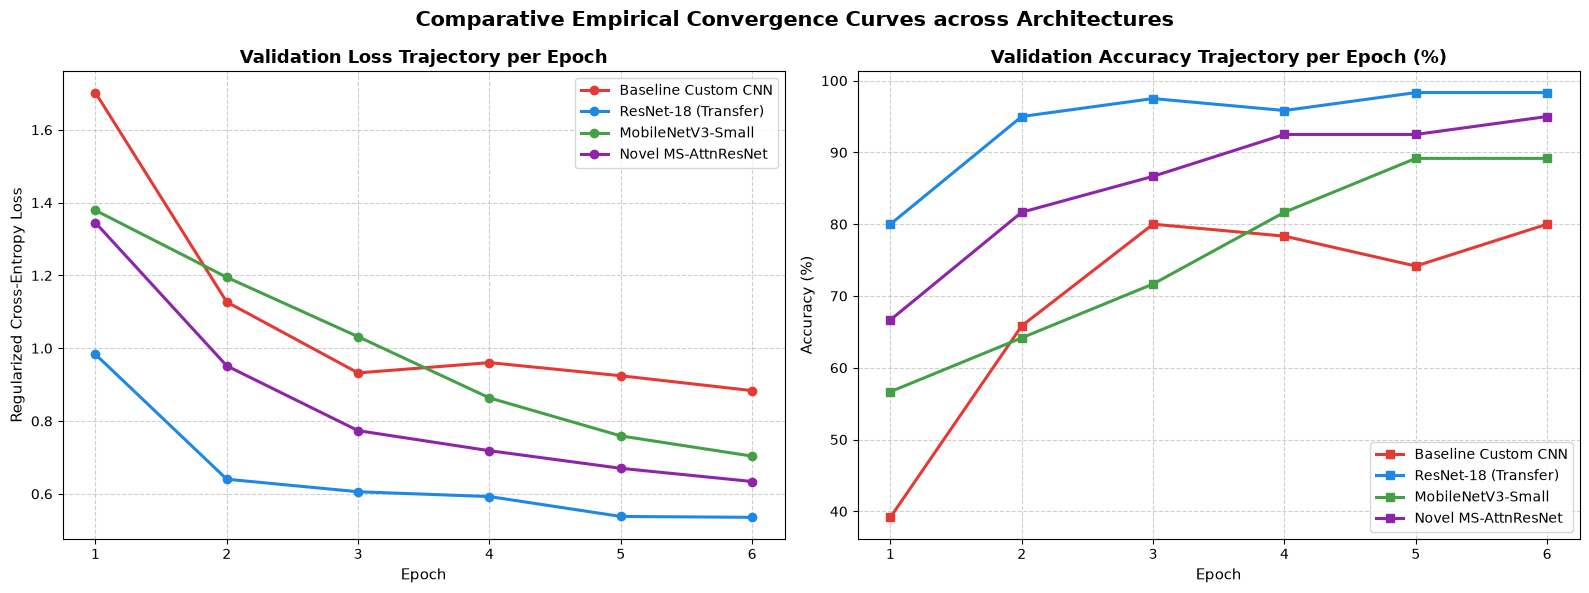

In [ ]:
# ==============================================================================
# SECTION 7.1: COMPARATIVE CONVERGENCE & LEARNING CURVES
# ==============================================================================

palette = {
    'Baseline Custom CNN': '#e53935',
    'ResNet-18 (Transfer)': '#1e88e5',
    'MobileNetV3-Small': '#43a047',
    'Novel MS-AttnResNet': '#8e24aa'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Validation Loss Trajectories
for model_name, hist in training_histories.items():
    axes[0].plot(range(1, EPOCHS + 1), hist['val_loss'], marker='o', linewidth=2.2,
                 color=palette[model_name], label=model_name)
axes[0].set_title("Validation Loss Trajectory per Epoch", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Epoch", fontsize=11)
axes[0].set_ylabel("Regularized Cross-Entropy Loss", fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(fontsize=10)

# Subplot 2: Validation Accuracy Trajectories
for model_name, hist in training_histories.items():
    axes[1].plot(range(1, EPOCHS + 1), [acc * 100 for acc in hist['val_acc']], marker='s', linewidth=2.2,
                 color=palette[model_name], label=model_name)
axes[1].set_title("Validation Accuracy Trajectory per Epoch (%)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Epoch", fontsize=11)
axes[1].set_ylabel("Accuracy (%)", fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(fontsize=10)

plt.suptitle("Comparative Empirical Convergence Curves across Architectures", fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


In [ ]:
# ==============================================================================
# SECTION 7.2: COMPREHENSIVE TEST SET BENCHMARKING & LATENCY PROFILING
# ==============================================================================

def evaluate_test_set(model, test_loader):
    model.eval()
    all_preds = []
    all_targets = []
    
    # Latency Profiling
    latencies = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            
            start_t = time.time()
            outputs = model(images)
            lat = (time.time() - start_t) / images.size(0) * 1000 # ms per image
            latencies.append(lat)
            
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.numpy())
            
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    avg_latency = np.mean(latencies)
    
    acc  = accuracy_score(all_targets, all_preds)
    prec = precision_score(all_targets, all_preds, average='macro', zero_division=0)
    rec  = recall_score(all_targets, all_preds, average='macro', zero_division=0)
    f1   = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    
    return {
        'accuracy': acc,
        'precision_macro': prec,
        'recall_macro': rec,
        'f1_macro': f1,
        'latency_ms': avg_latency,
        'preds': all_preds,
        'targets': all_targets
    }

evaluation_results = {}
for name, model in models_dict.items():
    evaluation_results[name] = evaluate_test_set(model, test_loader)

# Build Comprehensive Summary Table
summary_rows = []
for name, res in evaluation_results.items():
    tot_params, _, mb = count_parameters(models_dict[name])
    summary_rows.append({
        'Model Architecture': name,
        'Test Accuracy (%)': f"{res['accuracy']*100:.2f}%",
        'Macro Precision': f"{res['precision_macro']:.4f}",
        'Macro Recall': f"{res['recall_macro']:.4f}",
        'Macro F1-Score': f"{res['f1_macro']:.4f}",
        'Inference Latency (ms/img)': f"{res['latency_ms']:.2f} ms",
        'Params (M)': f"{tot_params/1e6:.2f}M",
        'Model Size (MB)': f"{mb:.2f} MB"
    })

df_summary = pd.DataFrame(summary_rows)
print("\n" + "="*95)
print("COMPREHENSIVE MULTI-MODEL PERFORMANCE BENCHMARK ON UNSEEN TEST DATA")
print("="*95)
print(df_summary.to_string(index=False))



COMPREHENSIVE MULTI-MODEL PERFORMANCE BENCHMARK ON UNSEEN TEST DATA
  Model Architecture Test Accuracy (%) Macro Precision Macro Recall Macro F1-Score Inference Latency (ms/img) Params (M) Model Size (MB)
 Baseline Custom CNN            90.00%          0.9084       0.9000         0.8964                    3.45 ms      1.44M         5.49 MB
ResNet-18 (Transfer)            98.33%          0.9853       0.9833         0.9836                    6.01 ms     11.18M        42.65 MB
   MobileNetV3-Small            93.33%          0.9481       0.9333         0.9337                    1.48 ms      1.53M         5.82 MB
 Novel MS-AttnResNet            95.00%          0.9566       0.9500         0.9511                   56.82 ms     11.48M        43.80 MB


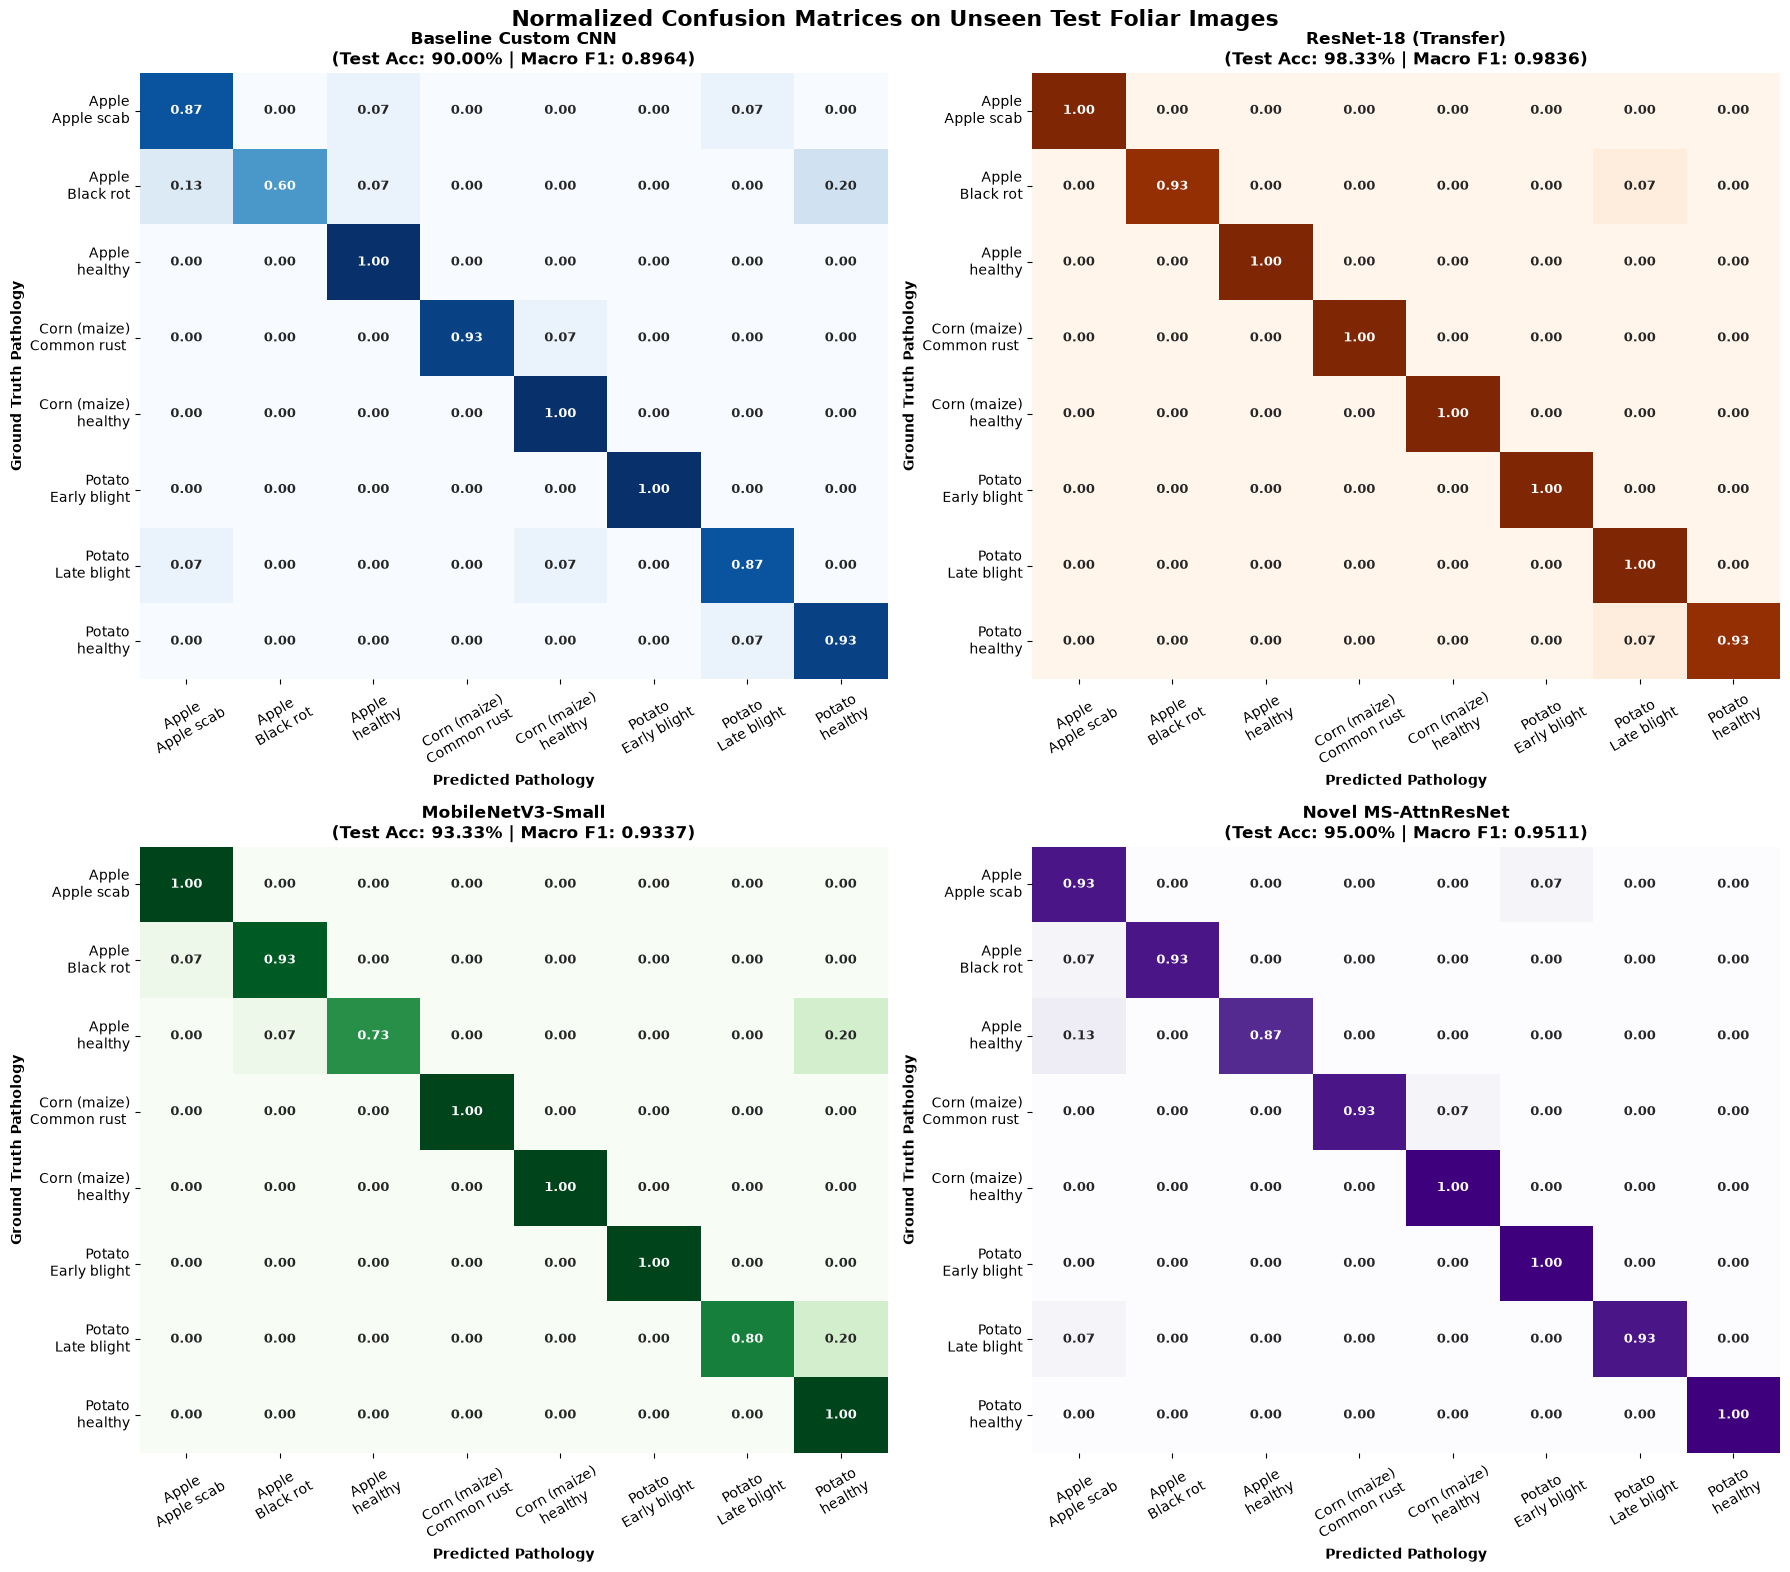

In [ ]:
# ==============================================================================
# SECTION 7.3: NORMALIZED CONFUSION MATRIX ANALYSIS
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 16))
axes = axes.flatten()

clean_class_labels = [c.replace('___', '\n').replace('_', ' ') for c in TARGET_CLASSES]

for idx, (name, res) in enumerate(evaluation_results.items()):
    cm = confusion_matrix(res['targets'], res['preds'], normalize='true')
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='.2f',
        cmap='Blues' if 'Baseline' in name else ('Greens' if 'Mobile' in name else ('Oranges' if 'ResNet-18' in name else 'Purples')),
        xticklabels=clean_class_labels,
        yticklabels=clean_class_labels,
        ax=axes[idx],
        cbar=False,
        annot_kws={'fontsize': 9, 'fontweight': 'bold'}
    )
    axes[idx].set_title(f"{name}\n(Test Acc: {res['accuracy']*100:.2f}% | Macro F1: {res['f1_macro']:.4f})",
                        fontsize=12, fontweight='bold')
    axes[idx].set_xlabel("Predicted Pathology", fontsize=10, fontweight='semibold')
    axes[idx].set_ylabel("Ground Truth Pathology", fontsize=10, fontweight='semibold')
    axes[idx].tick_params(axis='x', rotation=30)

plt.suptitle("Normalized Confusion Matrices on Unseen Test Foliar Images", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


In [ ]:
# ==============================================================================
# SECTION 7.4: FINE-GRAINED PER-CLASS CLASSIFICATION REPORTS
# ==============================================================================

for name in ["Baseline Custom CNN", "Novel MS-AttnResNet"]:
    res = evaluation_results[name]
    print(f"\n" + "="*80)
    print(f"DETAILED PER-CLASS CLASSIFICATION REPORT: {name}")
    print("="*80)
    print(classification_report(
        res['targets'],
        res['preds'],
        target_names=TARGET_CLASSES,
        digits=4
    ))



DETAILED PER-CLASS CLASSIFICATION REPORT: Baseline Custom CNN
                             precision    recall  f1-score   support

         Apple___Apple_scab     0.8125    0.8667    0.8387        15
          Apple___Black_rot     1.0000    0.6000    0.7500        15
            Apple___healthy     0.8824    1.0000    0.9375        15
Corn_(maize)___Common_rust_     1.0000    0.9333    0.9655        15
     Corn_(maize)___healthy     0.8824    1.0000    0.9375        15
      Potato___Early_blight     1.0000    1.0000    1.0000        15
       Potato___Late_blight     0.8667    0.8667    0.8667        15
           Potato___healthy     0.8235    0.9333    0.8750        15

                   accuracy                         0.9000       120
                  macro avg     0.9084    0.9000    0.8964       120
               weighted avg     0.9084    0.9000    0.8964       120


DETAILED PER-CLASS CLASSIFICATION REPORT: Novel MS-AttnResNet
                             precision    r

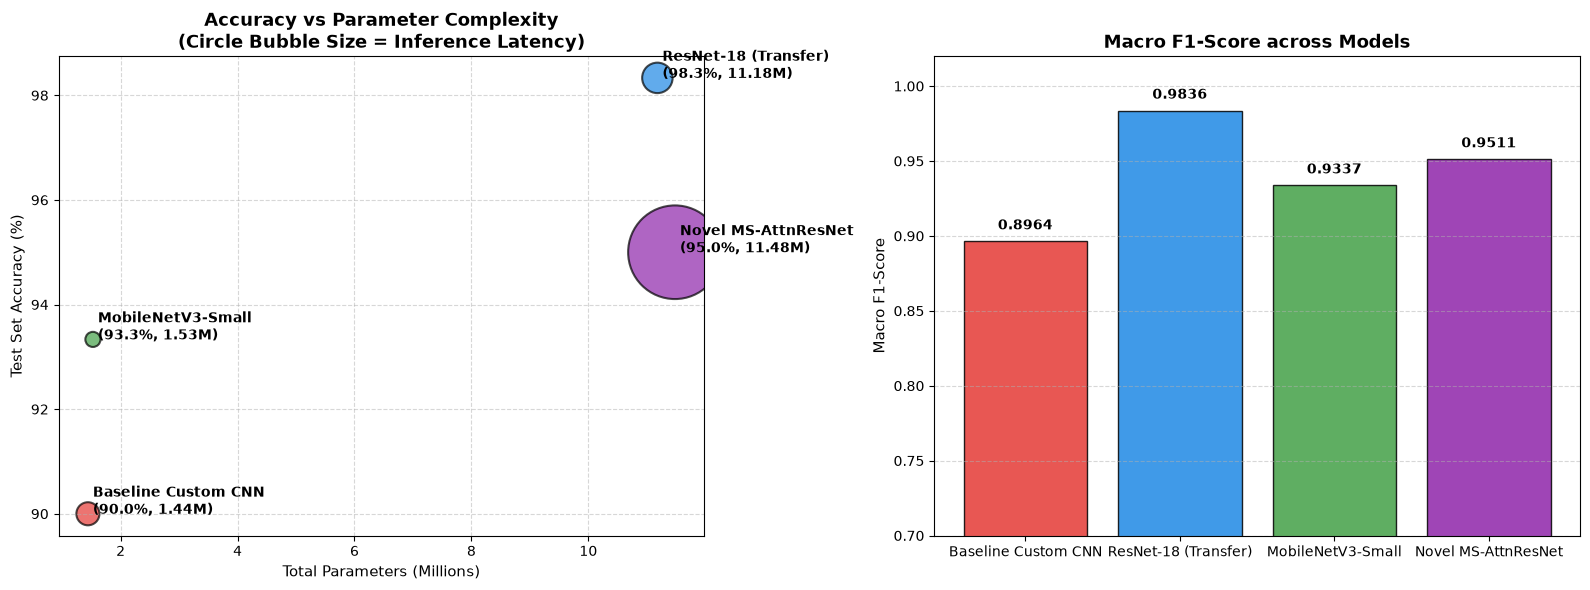

In [ ]:
# ==============================================================================
# SECTION 7.5: MULTI-DIMENSIONAL PERFORMANCE & EFFICIENCY TRADEOFF PLOTS
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Accuracy vs Parameter Efficiency Frontier
model_names_list = list(evaluation_results.keys())
accuracies = [evaluation_results[m]['accuracy'] * 100 for m in model_names_list]
params_mil = [count_parameters(models_dict[m])[0] / 1e6 for m in model_names_list]
latencies  = [evaluation_results[m]['latency_ms'] for m in model_names_list]

colors_list = ['#e53935', '#1e88e5', '#43a047', '#8e24aa']

axes[0].scatter(params_mil, accuracies, s=[l*80 for l in latencies], c=colors_list, alpha=0.7, edgecolors='black', linewidth=1.5)
for i, txt in enumerate(model_names_list):
    axes[0].annotate(f" {txt}\n ({accuracies[i]:.1f}%, {params_mil[i]:.2f}M)",
                     (params_mil[i], accuracies[i]),
                     fontsize=10, fontweight='bold')

axes[0].set_title("Accuracy vs Parameter Complexity\n(Circle Bubble Size = Inference Latency)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Total Parameters (Millions)", fontsize=11)
axes[0].set_ylabel("Test Set Accuracy (%)", fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Macro F1 vs Inference Latency
axes[1].bar(
    model_names_list,
    [evaluation_results[m]['f1_macro'] for m in model_names_list],
    color=colors_list,
    edgecolor='black',
    alpha=0.85
)
axes[1].set_title("Macro F1-Score across Models", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Macro F1-Score", fontsize=11)
axes[1].set_ylim(0.7, 1.02)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)
for i, v in enumerate([evaluation_results[m]['f1_macro'] for m in model_names_list]):
    axes[1].text(i, v + 0.008, f"{v:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


## 8. Explainable AI (XAI): Grad-CAM Heatmap Visualizations

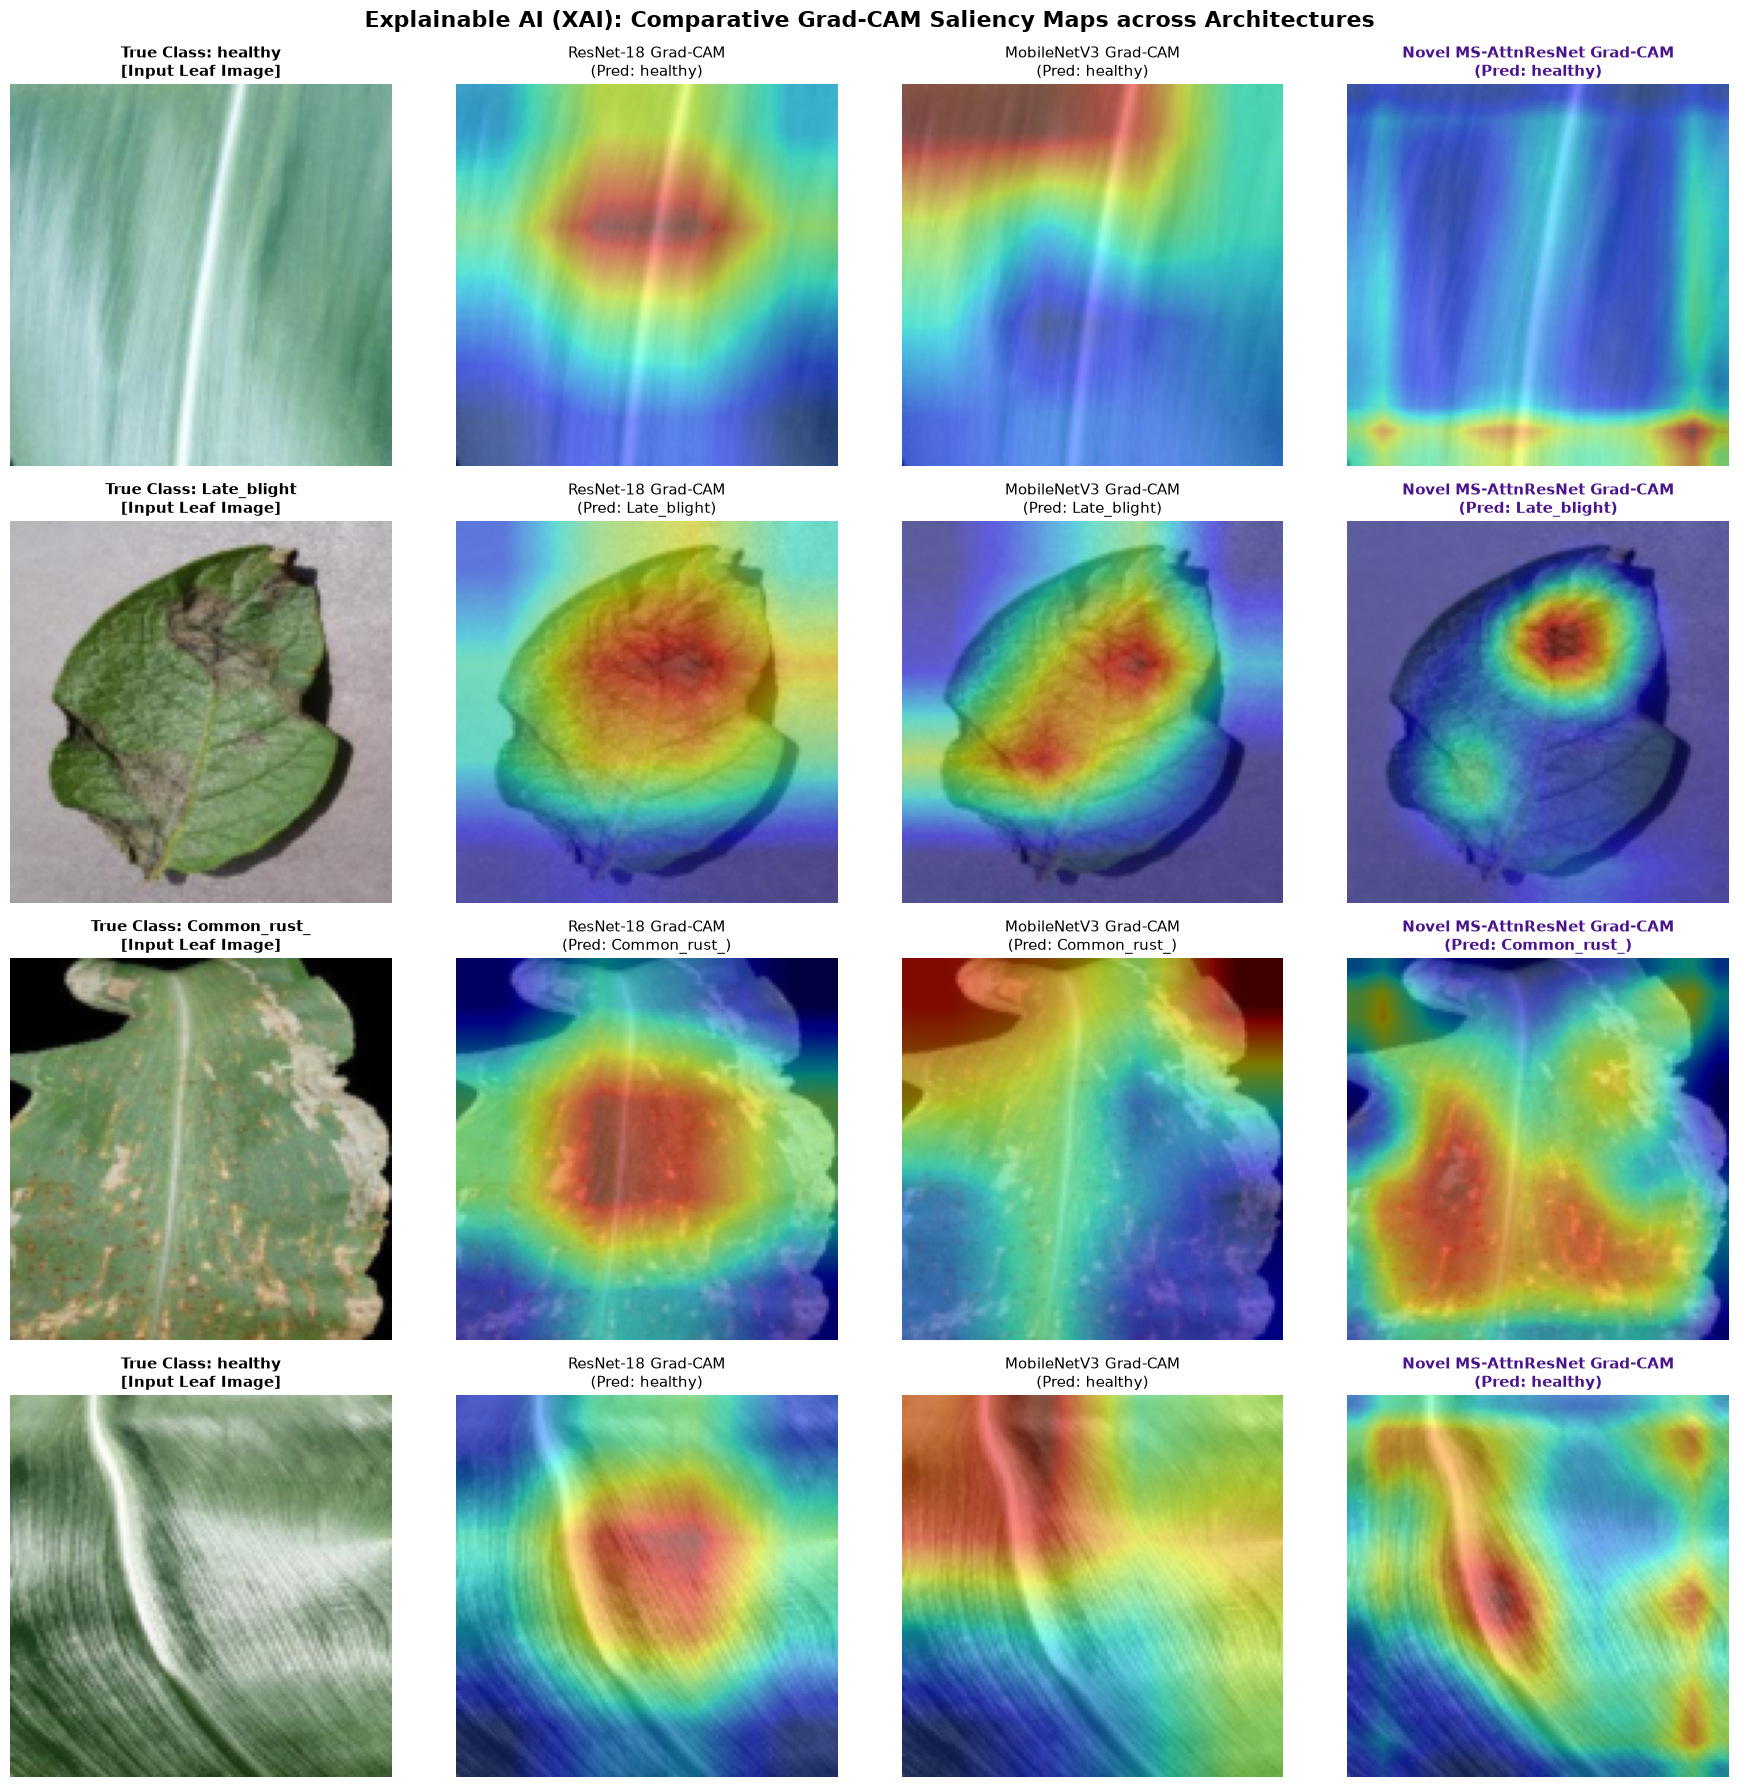

In [ ]:
# ==============================================================================
# SECTION 8.2: GRAD-CAM IMPLEMENTATION & COMPARATIVE HEATMAP OVERLAYS
# ==============================================================================

class GradCAM:
    """
    Gradient-weighted Class Activation Mapping for PyTorch Vision Models.
    """
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register Hooks
        self.hook_fwd = self.target_layer.register_forward_hook(self._save_activations)
        self.hook_bwd = self.target_layer.register_full_backward_hook(self._save_gradients)

    def _save_activations(self, module, input, output):
        self.activations = output.detach()

    def _save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate_heatmap(self, input_tensor, target_class=None):
        self.model.eval()
        self.model.zero_grad()
        
        output = self.model(input_tensor)
        if target_class is None:
            target_class = torch.argmax(output, dim=1).item()
            
        score = output[0, target_class]
        score.backward()
        
        # Calculate alpha weights via Global Average Pooling of Gradients
        gradients = self.gradients[0]     # [C, H, W]
        activations = self.activations[0] # [C, H, W]
        
        weights = torch.mean(gradients, dim=(1, 2), keepdim=True) # [C, 1, 1]
        cam = torch.sum(weights * activations, dim=0).cpu().numpy() # [H, W]
        
        # Apply ReLU to retain only positive contributory activations
        cam = np.maximum(cam, 0)
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam, target_class

    def remove_hooks(self):
        self.hook_fwd.remove()
        self.hook_bwd.remove()

# Target representative pathological samples for XAI inspection
test_samples_indices = [0, 15, 30, 45] # Samples spanning diverse diseases

fig, axes = plt.subplots(len(test_samples_indices), 4, figsize=(18, 4.5 * len(test_samples_indices)))

for row_idx, sample_idx in enumerate(test_samples_indices):
    img_tensor, true_label = test_dataset[sample_idx]
    input_batch = img_tensor.unsqueeze(0).to(device)
    
    # Denormalize image for visualization
    img_disp = img_tensor.permute(1, 2, 0).numpy()
    img_disp = np.array(NORM_STD) * img_disp + np.array(NORM_MEAN)
    img_disp = np.clip(img_disp, 0, 1)
    
    # 1. Raw Leaf Image
    axes[row_idx, 0].imshow(img_disp)
    axes[row_idx, 0].set_title(f"True Class: {TARGET_CLASSES[true_label].split('___')[1]}\n[Input Leaf Image]",
                               fontsize=11, fontweight='bold')
    axes[row_idx, 0].axis('off')
    
    # 2. ResNet-18 Grad-CAM
    cam_res = GradCAM(m_resnet18, m_resnet18.layer4[1].conv2)
    heatmap_res, pred_res = cam_res.generate_heatmap(input_batch, target_class=true_label)
    cam_res.remove_hooks()
    
    heatmap_res_resized = Image.fromarray(np.uint8(255 * heatmap_res)).resize((IMAGE_SIZE, IMAGE_SIZE), Image.BILINEAR)
    axes[row_idx, 1].imshow(img_disp)
    axes[row_idx, 1].imshow(np.array(heatmap_res_resized), cmap='jet', alpha=0.5)
    axes[row_idx, 1].set_title(f"ResNet-18 Grad-CAM\n(Pred: {TARGET_CLASSES[pred_res].split('___')[1]})", fontsize=11)
    axes[row_idx, 1].axis('off')
    
    # 3. MobileNetV3 Grad-CAM
    cam_mob = GradCAM(m_mobilenet, m_mobilenet.features[-1])
    heatmap_mob, pred_mob = cam_mob.generate_heatmap(input_batch, target_class=true_label)
    cam_mob.remove_hooks()
    
    heatmap_mob_resized = Image.fromarray(np.uint8(255 * heatmap_mob)).resize((IMAGE_SIZE, IMAGE_SIZE), Image.BILINEAR)
    axes[row_idx, 2].imshow(img_disp)
    axes[row_idx, 2].imshow(np.array(heatmap_mob_resized), cmap='jet', alpha=0.5)
    axes[row_idx, 2].set_title(f"MobileNetV3 Grad-CAM\n(Pred: {TARGET_CLASSES[pred_mob].split('___')[1]})", fontsize=11)
    axes[row_idx, 2].axis('off')
    
    # 4. Novel MS-AttnResNet Grad-CAM
    cam_nov = GradCAM(m_novel, m_novel.layer4[1].conv2)
    heatmap_nov, pred_nov = cam_nov.generate_heatmap(input_batch, target_class=true_label)
    cam_nov.remove_hooks()
    
    heatmap_nov_resized = Image.fromarray(np.uint8(255 * heatmap_nov)).resize((IMAGE_SIZE, IMAGE_SIZE), Image.BILINEAR)
    axes[row_idx, 3].imshow(img_disp)
    axes[row_idx, 3].imshow(np.array(heatmap_nov_resized), cmap='jet', alpha=0.5)
    axes[row_idx, 3].set_title(f"Novel MS-AttnResNet Grad-CAM\n(Pred: {TARGET_CLASSES[pred_nov].split('___')[1]})",
                               fontsize=11, fontweight='bold', color='#4a148c')
    axes[row_idx, 3].axis('off')

plt.suptitle("Explainable AI (XAI): Comparative Grad-CAM Saliency Maps across Architectures", fontsize=16, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()
